In [1]:
import sys
print(sys.version)

3.10.20 (main, Apr 30 2026, 02:41:12) [GCC 13.3.0]


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 12.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 4.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 11.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [13]:
import tensorflow as tf

train_dir = "fruit_dataset/train"
val_dir = "fruit_dataset/validation"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

Found 1182 files belonging to 6 classes.
Found 329 files belonging to 6 classes.
['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(class_names)

base_model = keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


2026-05-01 00:31:18.286107: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


37/37 [==============================] - ETA: 0s - loss: 0.4027 - accuracy: 0.8562

2026-05-01 00:31:37.532516: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


37/37 [==============================] - 35s 602ms/step - loss: 0.4027 - accuracy: 0.8562 - val_loss: 0.0960 - val_accuracy: 0.9696
Epoch 2/10
37/37 [==============================] - 15s 399ms/step - loss: 0.0642 - accuracy: 0.9797 - val_loss: 0.0701 - val_accuracy: 0.9787
Epoch 3/10
37/37 [==============================] - 15s 419ms/step - loss: 0.0373 - accuracy: 0.9898 - val_loss: 0.0656 - val_accuracy: 0.9818
Epoch 4/10
37/37 [==============================] - 15s 399ms/step - loss: 0.0201 - accuracy: 0.9983 - val_loss: 0.0672 - val_accuracy: 0.9787
Epoch 5/10
37/37 [==============================] - 15s 398ms/step - loss: 0.0121 - accuracy: 1.0000 - val_loss: 0.0667 - val_accuracy: 0.9757
Epoch 6/10
37/37 [==============================] - 15s 401ms/step - loss: 0.0098 - accuracy: 1.0000 - val_loss: 0.0699 - val_accuracy: 0.9757
Epoch 7/10
37/37 [==============================] - 15s 400ms/step - loss: 0.0074 - accuracy: 1.0000 - val_loss: 0.0684 - val_accuracy: 0.9757
Epoch 8/10

In [21]:
!pip install matplotlib

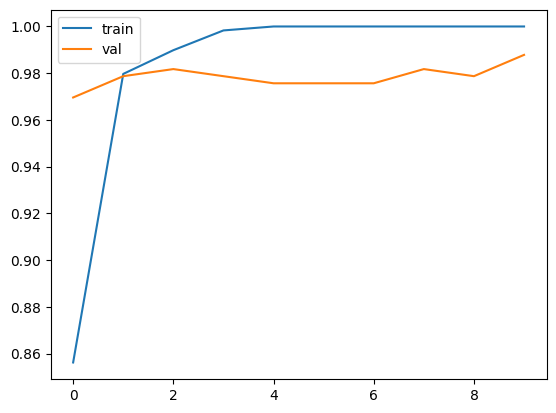

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

1/1 [==============================] - 1s 1s/step


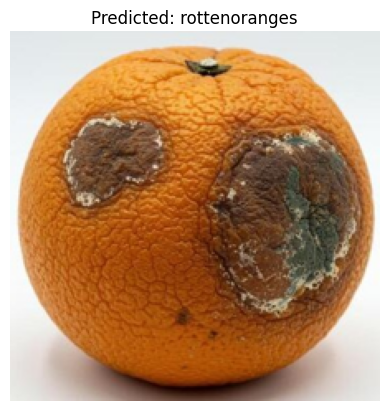

In [24]:
from PIL import Image
import numpy as np

img = Image.open("fruit_dataset/test/Test 1.jpeg").resize((224, 224))
img_array = normalization_layer(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions[0])]

import matplotlib.pyplot as plt

plt.imshow(img_array[0])  # remove batch dim
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

1/1 [==============================] - 0s 74ms/step


(-0.5, 223.5, 223.5, -0.5)

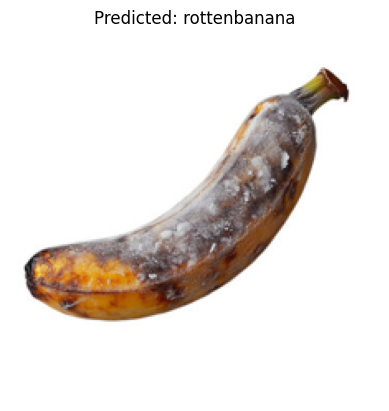

In [25]:
img = Image.open("fruit_dataset/test/Test 2.jpeg").resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions[0])]

import matplotlib.pyplot as plt

plt.imshow(img_array[0])  # remove batch dim
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")

1/1 [==============================] - 0s 68ms/step


(-0.5, 223.5, 223.5, -0.5)

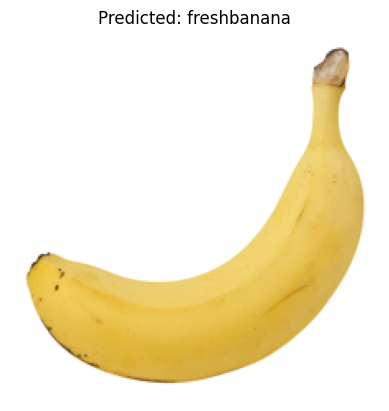

In [26]:
img = Image.open("fruit_dataset/test/Test 3.jpg").resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions[0])]

import matplotlib.pyplot as plt

plt.imshow(img_array[0])  # remove batch dim
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")